# 1. Install library

# 2. Importing library and defining plotting functions

In [4]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import mmcfilters
import pandas as pd
import math

from IPython import display
np.set_printoptions(suppress=True) 

from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back

def printSimpleTree():
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID:{node.id}\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}",
        color=Back.BLACK + Fore.WHITE,
    )
    return printTree

def printTreeWithAttribute(attrType, attrValue):
    printTree = PrettyPrintTree(
        lambda node: node.children,
        lambda node: f"ID: {node.id}\nLevel: {node.level}\n|cnps|: {len(node.cnps)}\nArea: {node.area}\n{attrType.name}: {attrValue[node.id]}",
        color=Back.BLACK + Fore.WHITE
    )
    return printTree


def showLevelSets(img_f):
    print("Upper and lower level sets where in black are foreground pixels and white are background pixels")
    t_values = np.unique(img_f)
    len = np.size(t_values)
    max_value = np.max(img_f)
    fig, axes = plt.subplots(len, 2, figsize=(5, 15))

    # Preenchendo os subplots com imagens limiares
    for i, t in enumerate(t_values):
        # Primeira coluna: img_f >= t
        thr = t_values[i]
        img_threshold_ge = np.where(img_f >= thr, 1, 0)
        axes[i, 0].imshow(img_threshold_ge, cmap='gray_r', vmax=1, vmin=0, interpolation='nearest')
        axes[i, 0].set_title(f'image ≥ {t}')
        axes[i, 0].axis('off')
        axes[i, 0].add_patch(plt.Rectangle((0, 0), img_threshold_ge.shape[1] - 1, img_threshold_ge.shape[0] - 1,
                                   edgecolor='red', linewidth=0.5, fill=False))
        # Segunda coluna: img_f <= t
        thr = t_values[len - i -1]
        img_threshold_le = np.where(img_f <= thr, 1, 0)
        axes[i, 1].imshow(img_threshold_le, cmap='gray_r',vmax=1, vmin=0, interpolation='nearest')
        axes[i, 1].set_title(f'image ≤ {thr}')
        axes[i, 1].axis('off')
        axes[i, 1].add_patch(plt.Rectangle((0, 0), img_threshold_le.shape[1] - 1, img_threshold_le.shape[0] - 1,
                                   edgecolor='blue', linewidth=0.5, fill=False))

    # Ajuste de layout para evitar sobreposição
    plt.tight_layout()
    plt.show()


def computeCentroid(cnps):
    closest_pixel = cnps[len(cnps)//2]
    px, py = closest_pixel // num_cols, closest_pixel % num_cols
    return px, py

def showTree(tree, printTree=printSimpleTree()):
    if(tree.treeType == 0):
        print("Imagem and its max-tree representation. The indexes of max-tree nodes are shown as label in the imagem.")
    elif(tree.treeType == 1):
        print("Imagem and its min-tree representation. The indexes of min-tree nodes are shown as label in the imagem.")
    else:
        print("Imagem and its tree of shapes representation. The indexes of tree of shapes nodes are shown as label in the imagem.")
    img_vector = tree.reconstructionImage()
    ids_position = []

    for node in tree.root.postOrderTraversal():
      px, py = computeCentroid(node.cnps)
      ids_position.append( (node.id, px, py) )

    # Plota a imagem
    plt.figure(figsize=(8, 6))
    image = img_vector.reshape(tree.numRows, tree.numCols)
    # Adicionando uma borda ao redor da imagem
    ax = plt.gca()  # Obtém o eixo atual
    ax.add_patch(plt.Rectangle((0, 0), image.shape[1] - 1, image.shape[0] - 1,
                               edgecolor='red', linewidth=0.5, fill=False))

    plt.imshow(image, cmap='gray')

    # Adiciona rótulos nos centróides fictícios
    for i, (id, x, y) in enumerate(ids_position):
        plt.text(y, x, f'•{id}', color='red', fontsize=9)


    plt.axis('off')
    plt.show()
    printTree(tree.root)

def showNode(node):
    image = node.recNode().reshape(num_rows, num_cols)
    ax = plt.gca()  # Obtém o eixo atual
    ax.imshow(image, cmap='gray_r')
    ax.add_patch(plt.Rectangle((0, 0), image.shape[1] - 1, image.shape[0] - 1,
                               edgecolor='red', linewidth=0.5, fill=False))
    ax.set_title(f"{node}")
    ax.axis("off")

def buildMapIds(tree):
    mapIds = np.zeros(num_rows*num_cols)
    for p in range(num_rows*num_cols):
        mapIds[p] = tree.getSC(p).id
    return mapIds


import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

def getNodeContour(tree, node):
    adj = mta.AdjacencyRelation(num_rows, num_cols, 1.5)  # Relação de adjacência
    contour = []

    for idP in node.cnps:  # Percorre os pixels do nó
        for idQ in adj.getAdjPixels(idP):  # Verifica seus vizinhos
            sc_p = tree.getSC(idP)
            sc_q = tree.getSC(idQ)

            if sc_p and sc_q and sc_p.id != sc_q.id:  # Verifica se são nós diferentes
                pixel_x = idQ // num_cols
                pixel_y = idQ % num_cols
                contour.append((pixel_y, pixel_x))  # (x=coluna, y=linha)

    return contour

def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

# 3. Creating the morphological tree of an input image

Upper and lower level sets where in black are foreground pixels and white are background pixels


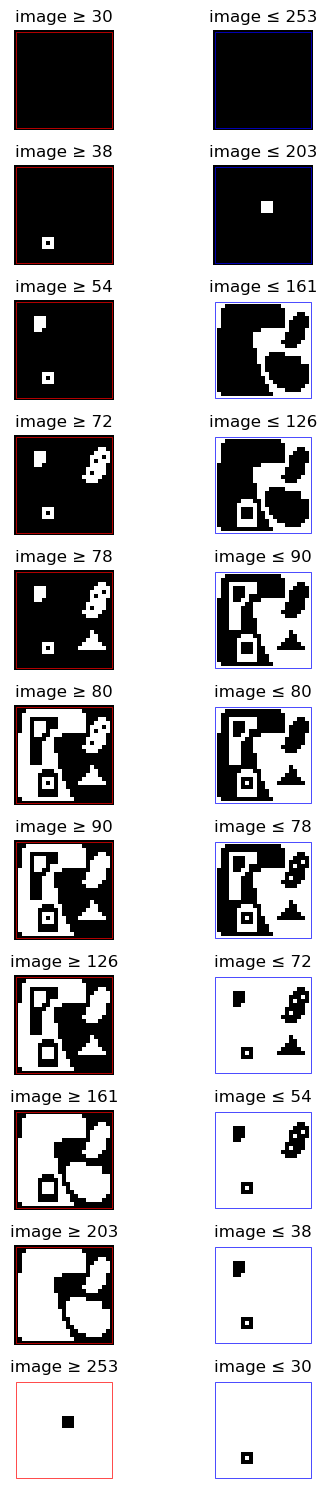




Imagem and its max-tree representation. The indexes of max-tree nodes are shown as label in the imagem.


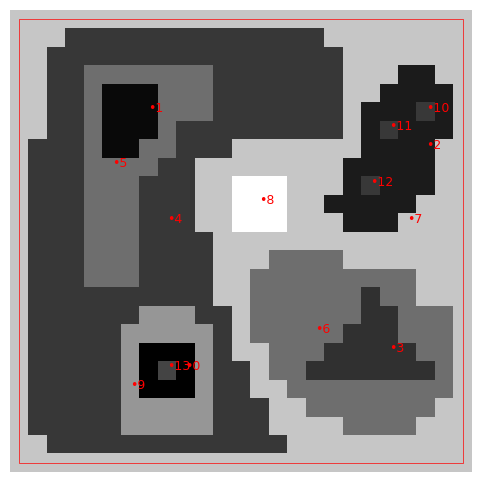

                                                          ID:0      
                                                          Level: 30 
                                                          |cnps|: 8 
                                                          Area: 625 
                                           ┌──────────────────┴──────────────────┐
                                       ID:1                                  ID:13     
                                       Level: 38                             Level: 90 
                                       |cnps|: 11                            |cnps|: 1 
                                       Area: 616                             Area: 1   
                                           |                                           
                                       ID:2                                            
                                       Level: 54                                       
                         

In [6]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

imgInput = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,253,253,253,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)
(num_rows, num_cols) = imgInput.shape

isMaxtree = True
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, isMaxtree)

showLevelSets(imgInput)
print("\n\n")
showTree(tree)

# 4. Computing a single attribute

Imagem and its max-tree representation. The indexes of max-tree nodes are shown as label in the imagem.

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 


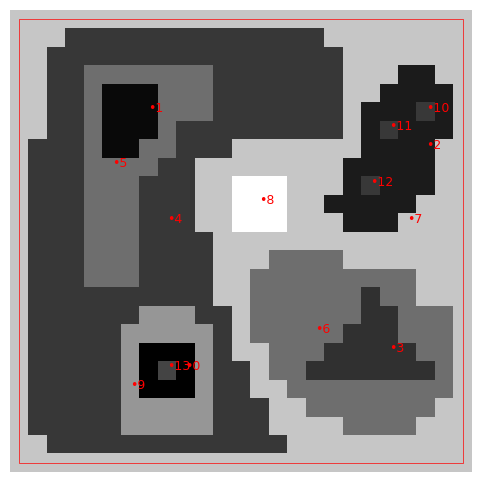

                                                                                       ID: 0              
                                                                                       Level: 30          
                                                                                       |cnps|: 8          
                                                                                       Area: 625          
                                                                                       GRAY_HEIGHT: 224.0 
                                                                  ┌────────────────────────────┴────────────────────────────┐
                                                          ID: 1                                                      ID: 13           
                                                          Level: 38                                                  Level: 90        
                                                          |cnps|: 11 

In [8]:
Type = mmcfilters.Attribute.Type

attrType = Type.GRAY_HEIGHT
attrValue = mmcfilters.Attribute.computeSingleAttribute(tree, attrType)
showTree(tree, printTreeWithAttribute(attrType, attrValue))

print(f"{attrType.name} (numpy): {attrValue}")

In [9]:
Type = mmcfilters.Attribute.Type


dic, attrs = mmcfilters.Attribute.computeAttributes(tree, [Type.AREA, Type.VOLUME, Type.BOX_HEIGHT])
pd.DataFrame(attrs, columns=dic, index=pd.Index(range(len(attrs)), name="NodeID"))


==== AttributeComputer: Computing AREA

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing BOUNDING_BOX group


,AREA,VOLUME,BOX_HEIGHT
NodeID,,,
0,625.0,25.0,3864.0
1,82872.0,42.0,7.0
2,25.0,5292.0,1.0
3,616.0,12.0,80.0
4,82542.0,292.0,1.0
5,25.0,54644.0,1.0
6,605.0,25.0,80.0
7,82124.0,226.0,1.0
8,25.0,46328.0,1.0


In [13]:
dic, attrs = mmcfilters.Attribute.computeSingleAttributeWithDelta(tree, Type.AREA, 2, "nan-padding")
pd.DataFrame(attrs, columns=dic, index=pd.Index(range(len(attrs)), name="NodeID"))


==== AttributeComputer: Computing AREA


,AREA_ASC_2,AREA_ASC_1,AREA,AREA_DESC_1,AREA_DESC_2
NodeID,,,,,
0,NaN,NaN,625.0,616.0,605.0
1,NaN,625.0,616.0,605.0,567.0
2,625.0,616.0,605.0,567.0,549.0
3,616.0,605.0,567.0,549.0,292.0
4,605.0,567.0,549.0,292.0,226.0
5,567.0,549.0,42.0,NaN,NaN
6,567.0,549.0,292.0,226.0,9.0
7,549.0,292.0,226.0,9.0,NaN
8,292.0,226.0,9.0,NaN,NaN


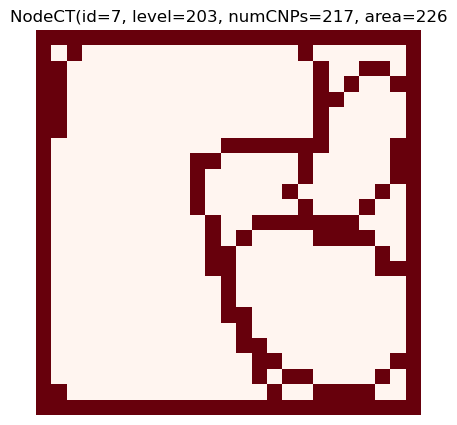

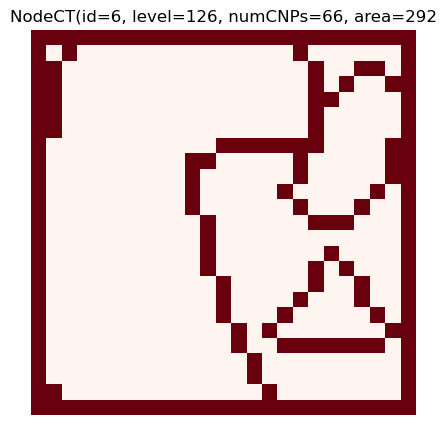

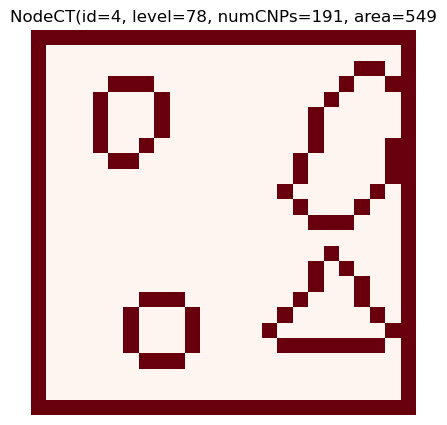

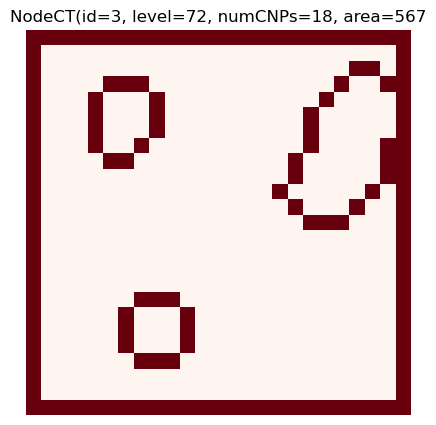

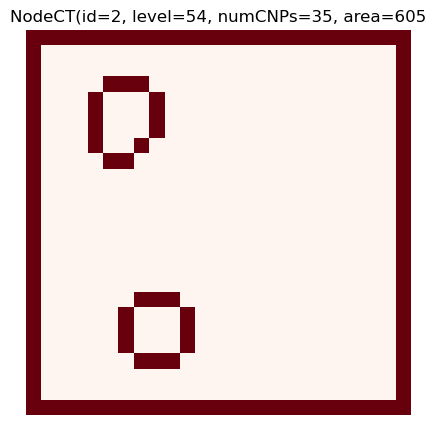

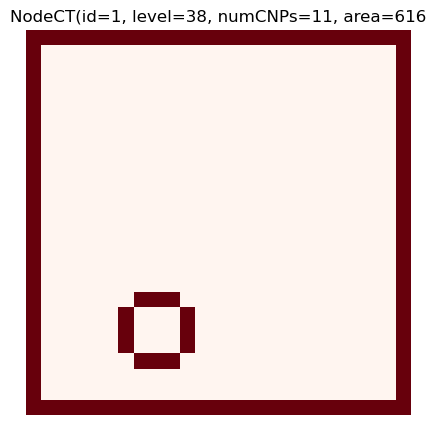

In [22]:
contoursMT = mmcfilters.Attribute.extractCountors(tree)
for [node, countor] in contoursMT.contours(tree.root):
    if (node.area > 100):
        plotCountors(countor, node, num_rows, num_cols)

In [24]:
attr_type = mmcfilters.Attribute.BOX_HEIGHT
threshold = 50

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

KeyError: 'BOX_HEIGHT'

Text(0.5, 1.0, 'attribute filter (tos)')

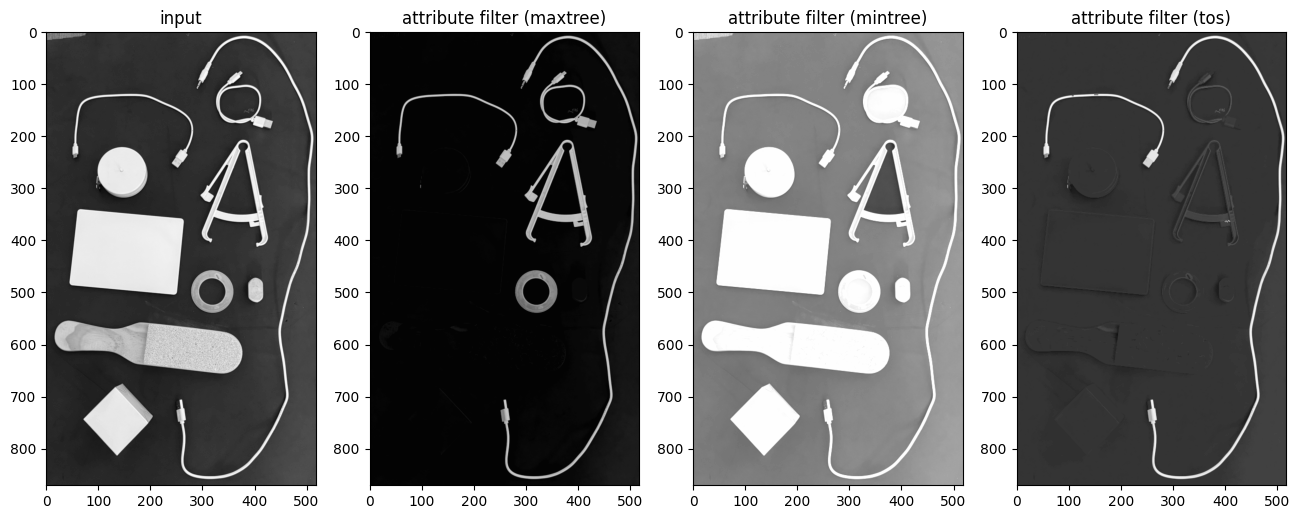

In [9]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.2

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'negative residues')

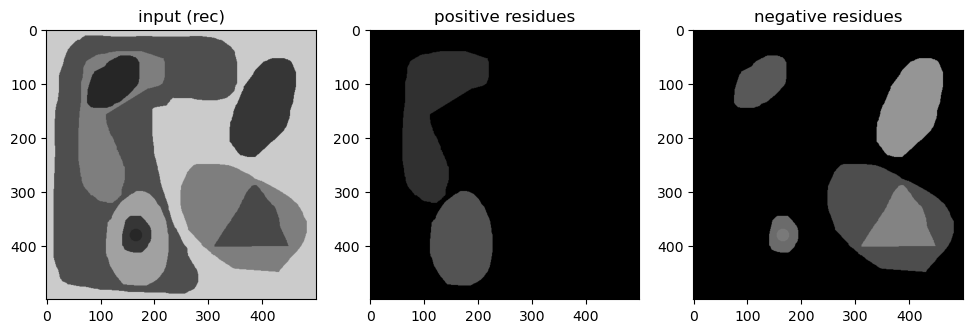

In [23]:
attr_type = dic['BOX_HEIGHT']
max_threshold = 300
attr_tos = attrs_tos[:,attr_type]
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


Text(0.5, 1.0, 'residual filter')

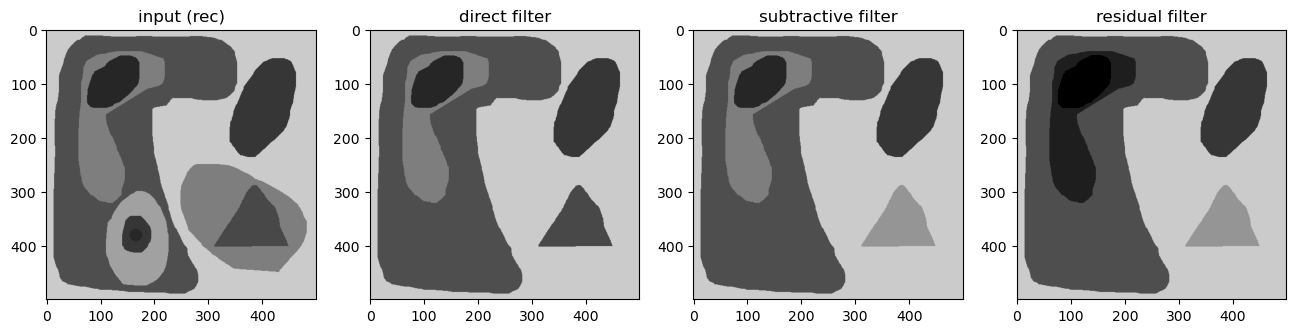

In [25]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
